In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from numpy import trapezoid
from scipy.optimize import curve_fit
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

In [2]:
eta_0 = 0.313
_eta = ["1.1", "1.2", "1.3", "1.4", "1.5", "1.6", "1.7", "1.8", "1.9", "2.0", "3.0", "4.0", 
       "5.0", "6.0", "7.0", "8.0", "9.0", "10.0", "20.0", "30.0", "40.0", "100.0"]

In [3]:
def F(x, A, B, C, D):
    # return A*np.exp((x-B)*C)+D
    # return A + B *np.log10(1 - (x-C))*np.exp(D*x)
    # return A+B*np.log(1 - (C*x)**2)
    return A+B/(1-(x-D))**C

In [4]:
A_min = -18
A_max = -14

B_min = -3.4
B_max = -1.5

C_min =  2.1
C_max =  4.7

D_min = -0.9
D_max = -0.1

In [5]:
def plot_fit_single(particle, eta, theta):
    fig, ax = plt.subplots(1,1,figsize = (8, 4))

    ax.set_title(rf"$\eta$ = {eta} $\eta_{0}$,  $\theta$ = {theta}$\degree$")

    interp_file = (
        f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
    )

    x_i, spectrum = np.genfromtxt(
        interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
    )
    x_i = np.log10(np.where(x_i>0,x_i,1e-100))
    spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

    ax.plot(x_i,spectrum,lw=2,label=r"SOPHIA")

    mask = (x_i >= -3) & (x_i <= 0)

    x_fit = x_i[mask]
    y_fit = spectrum[mask]

    count = 0
    for ii in range(0,6):
        if(y_fit[len(y_fit)-ii-1] < -50.):
            count=count+1
    if count!=0:
        x_fit = x_fit[:-count]
        y_fit = y_fit[:-count]

    # popt, pcov = curve_fit(F, x_fit, y_fit)
    popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([A_min, B_min, C_min, D_min],
                                                    [A_max, B_max, C_max, D_max]))
    print(popt)

    F_i = np.append(F(x_i, *popt),-100.)
    x_i = np.append(x_i,0.)

    ax.plot(x_i, F_i,lw=2,label=r"Fit")

    ax.set_xlabel("x")
    ax.set_ylabel("f")

    # ax.set_xlim(1e-4,1)
    # ax.set_ylim(1e-21,1e-14)
    ax.set_ylim(-21,-14)

[-16.99080836  -1.5          3.48402234  -0.43396019]
[-16.24824502  -3.4          3.4186356   -0.21383195]
[-16.13737094  -1.5          3.82684858  -0.473699  ]
[-16.06283349  -1.5          3.50874519  -0.47340778]


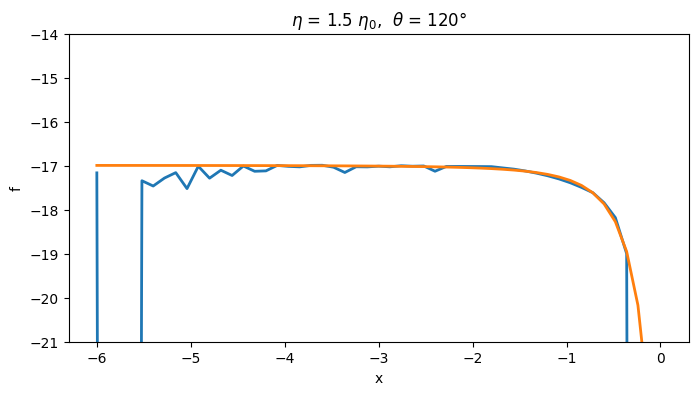

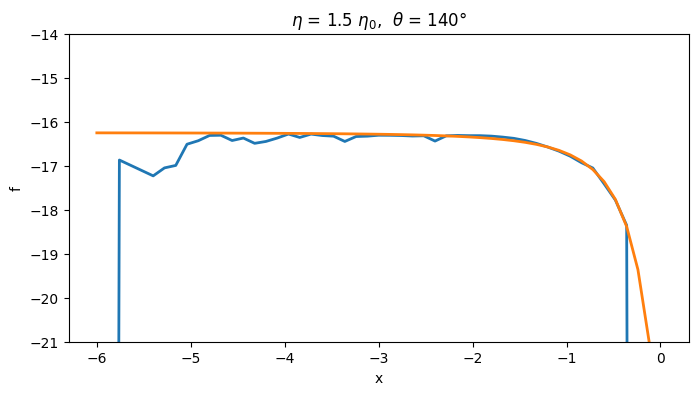

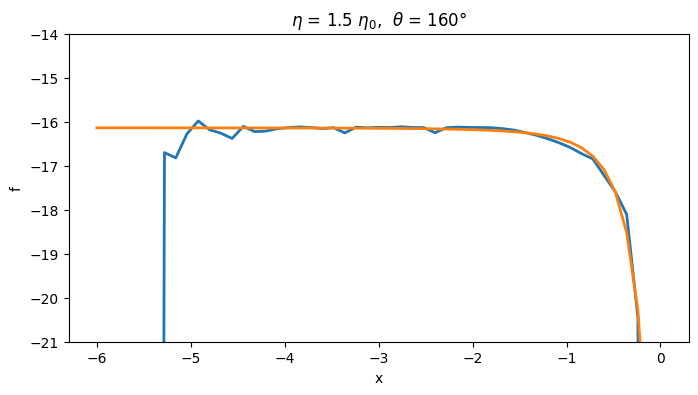

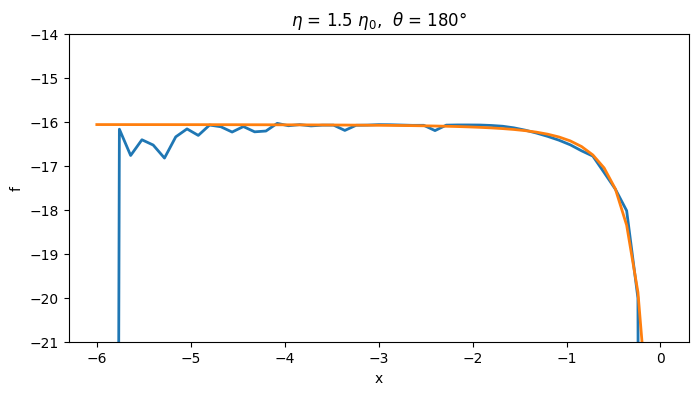

In [6]:
eta_eta0 = 1.5
particle = "photon"
plot_fit_single(particle, eta_eta0, 120)
plot_fit_single(particle, eta_eta0 ,140)
plot_fit_single(particle, eta_eta0 ,160)
plot_fit_single(particle, eta_eta0 ,180)

[-14.94101571  -3.4          2.1         -0.38748475]
[-14.85149063  -3.4          2.1         -0.39017887]
[-14.7963656   -3.4          2.1         -0.39624804]
[-14.76523091  -3.4          2.1         -0.40719049]


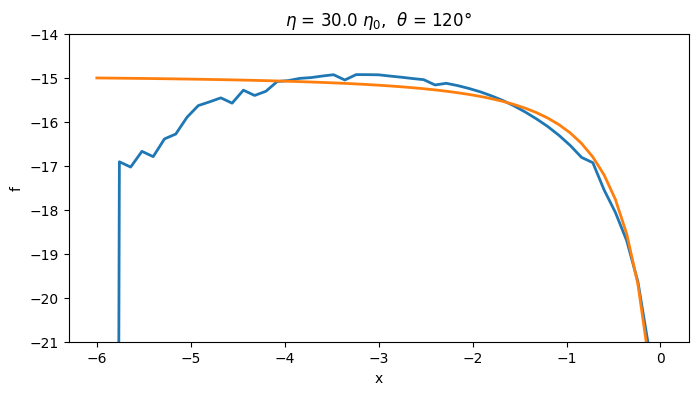

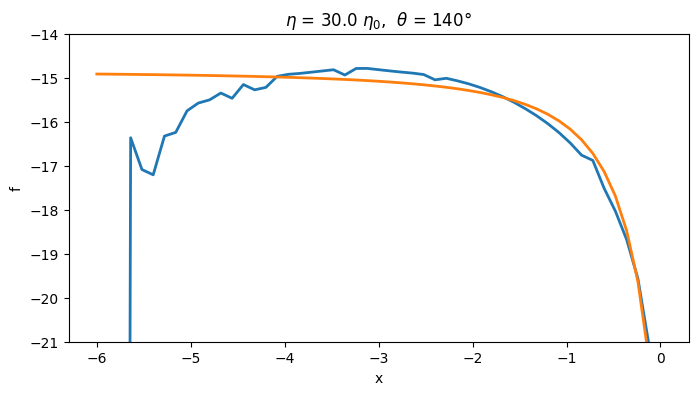

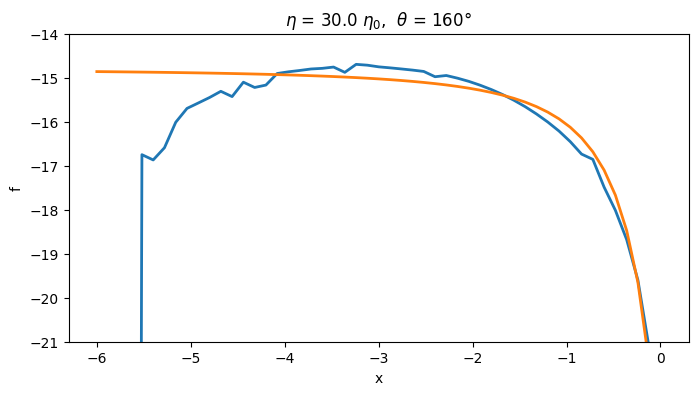

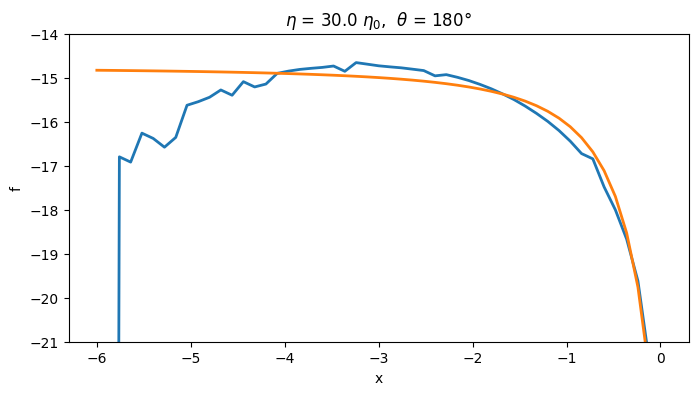

In [7]:
eta_eta0 = 30.0
particle = "photon"
plot_fit_single(particle, eta_eta0, 120)
plot_fit_single(particle, eta_eta0 ,140)
plot_fit_single(particle, eta_eta0 ,160)
plot_fit_single(particle, eta_eta0 ,180)

In [8]:
def fit_plot(particle):
    fig, ax = plt.subplots(22,19,figsize = (35, 20))

    fig.suptitle("Particle type: " + particle, fontsize=20)

    File = open(f"./integrand_values/Fx_{particle}.txt","w")

    print("#eta_eta0 | theta | A | B | C | D    ||   F(x, A, B, C, D, E) = A*np.pow(E,(x-B)*C)+D", file=File)

    i = 0
    for eta in _eta:
        j = 0
        for theta in range(0,190,10):
            interp_file = (
                f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
            )

            x_i, spectrum = np.genfromtxt(
                interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
            )
            if(np.any(spectrum) == True):
                x_i = np.log10(np.where(x_i>0,x_i,1e-100))
                spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

                ax[i,j].plot(x_i,spectrum,lw=2,label=r"SOPHIA")

                mask = (x_i >= -3) & (x_i <= 0)

                x_fit = x_i[mask]
                y_fit = spectrum[mask]

                count = 0
                for ii in range(0,6):
                    if(y_fit[len(y_fit)-ii-1] < -50.):
                        count=count+1
                if count!=0:
                    x_fit = x_fit[:-count]
                    y_fit = y_fit[:-count]

                popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([A_min, B_min, C_min, D_min],
                                                                [A_max, B_max, C_max, D_max]))

                F_i = np.append(F(x_i, *popt),-100.)
                x_i = np.append(x_i,0.)

                # print(*popt, x_i[-2], file=File)
                print(eta,theta,*popt, file=File)

                ax[i,j].plot(x_i, F_i, lw=2, label=r"Fit")

                ax[i,j].set_xlim(-5,0)
                ax[i,j].set_ylim(-21,-14)
            else:
                # print(eta,theta, -100., 0., 0., -100., 0., file=File)
                print(eta,theta, -100., -100., 0., 0., file=File)

            if i==0:
                ax[0,j].set_title(str(theta)+r"$\degree$")

            j = j+1
        
        ax[i,0].set_ylabel(eta+r" $\eta_{0}$")
        i=i+1

    File.close()


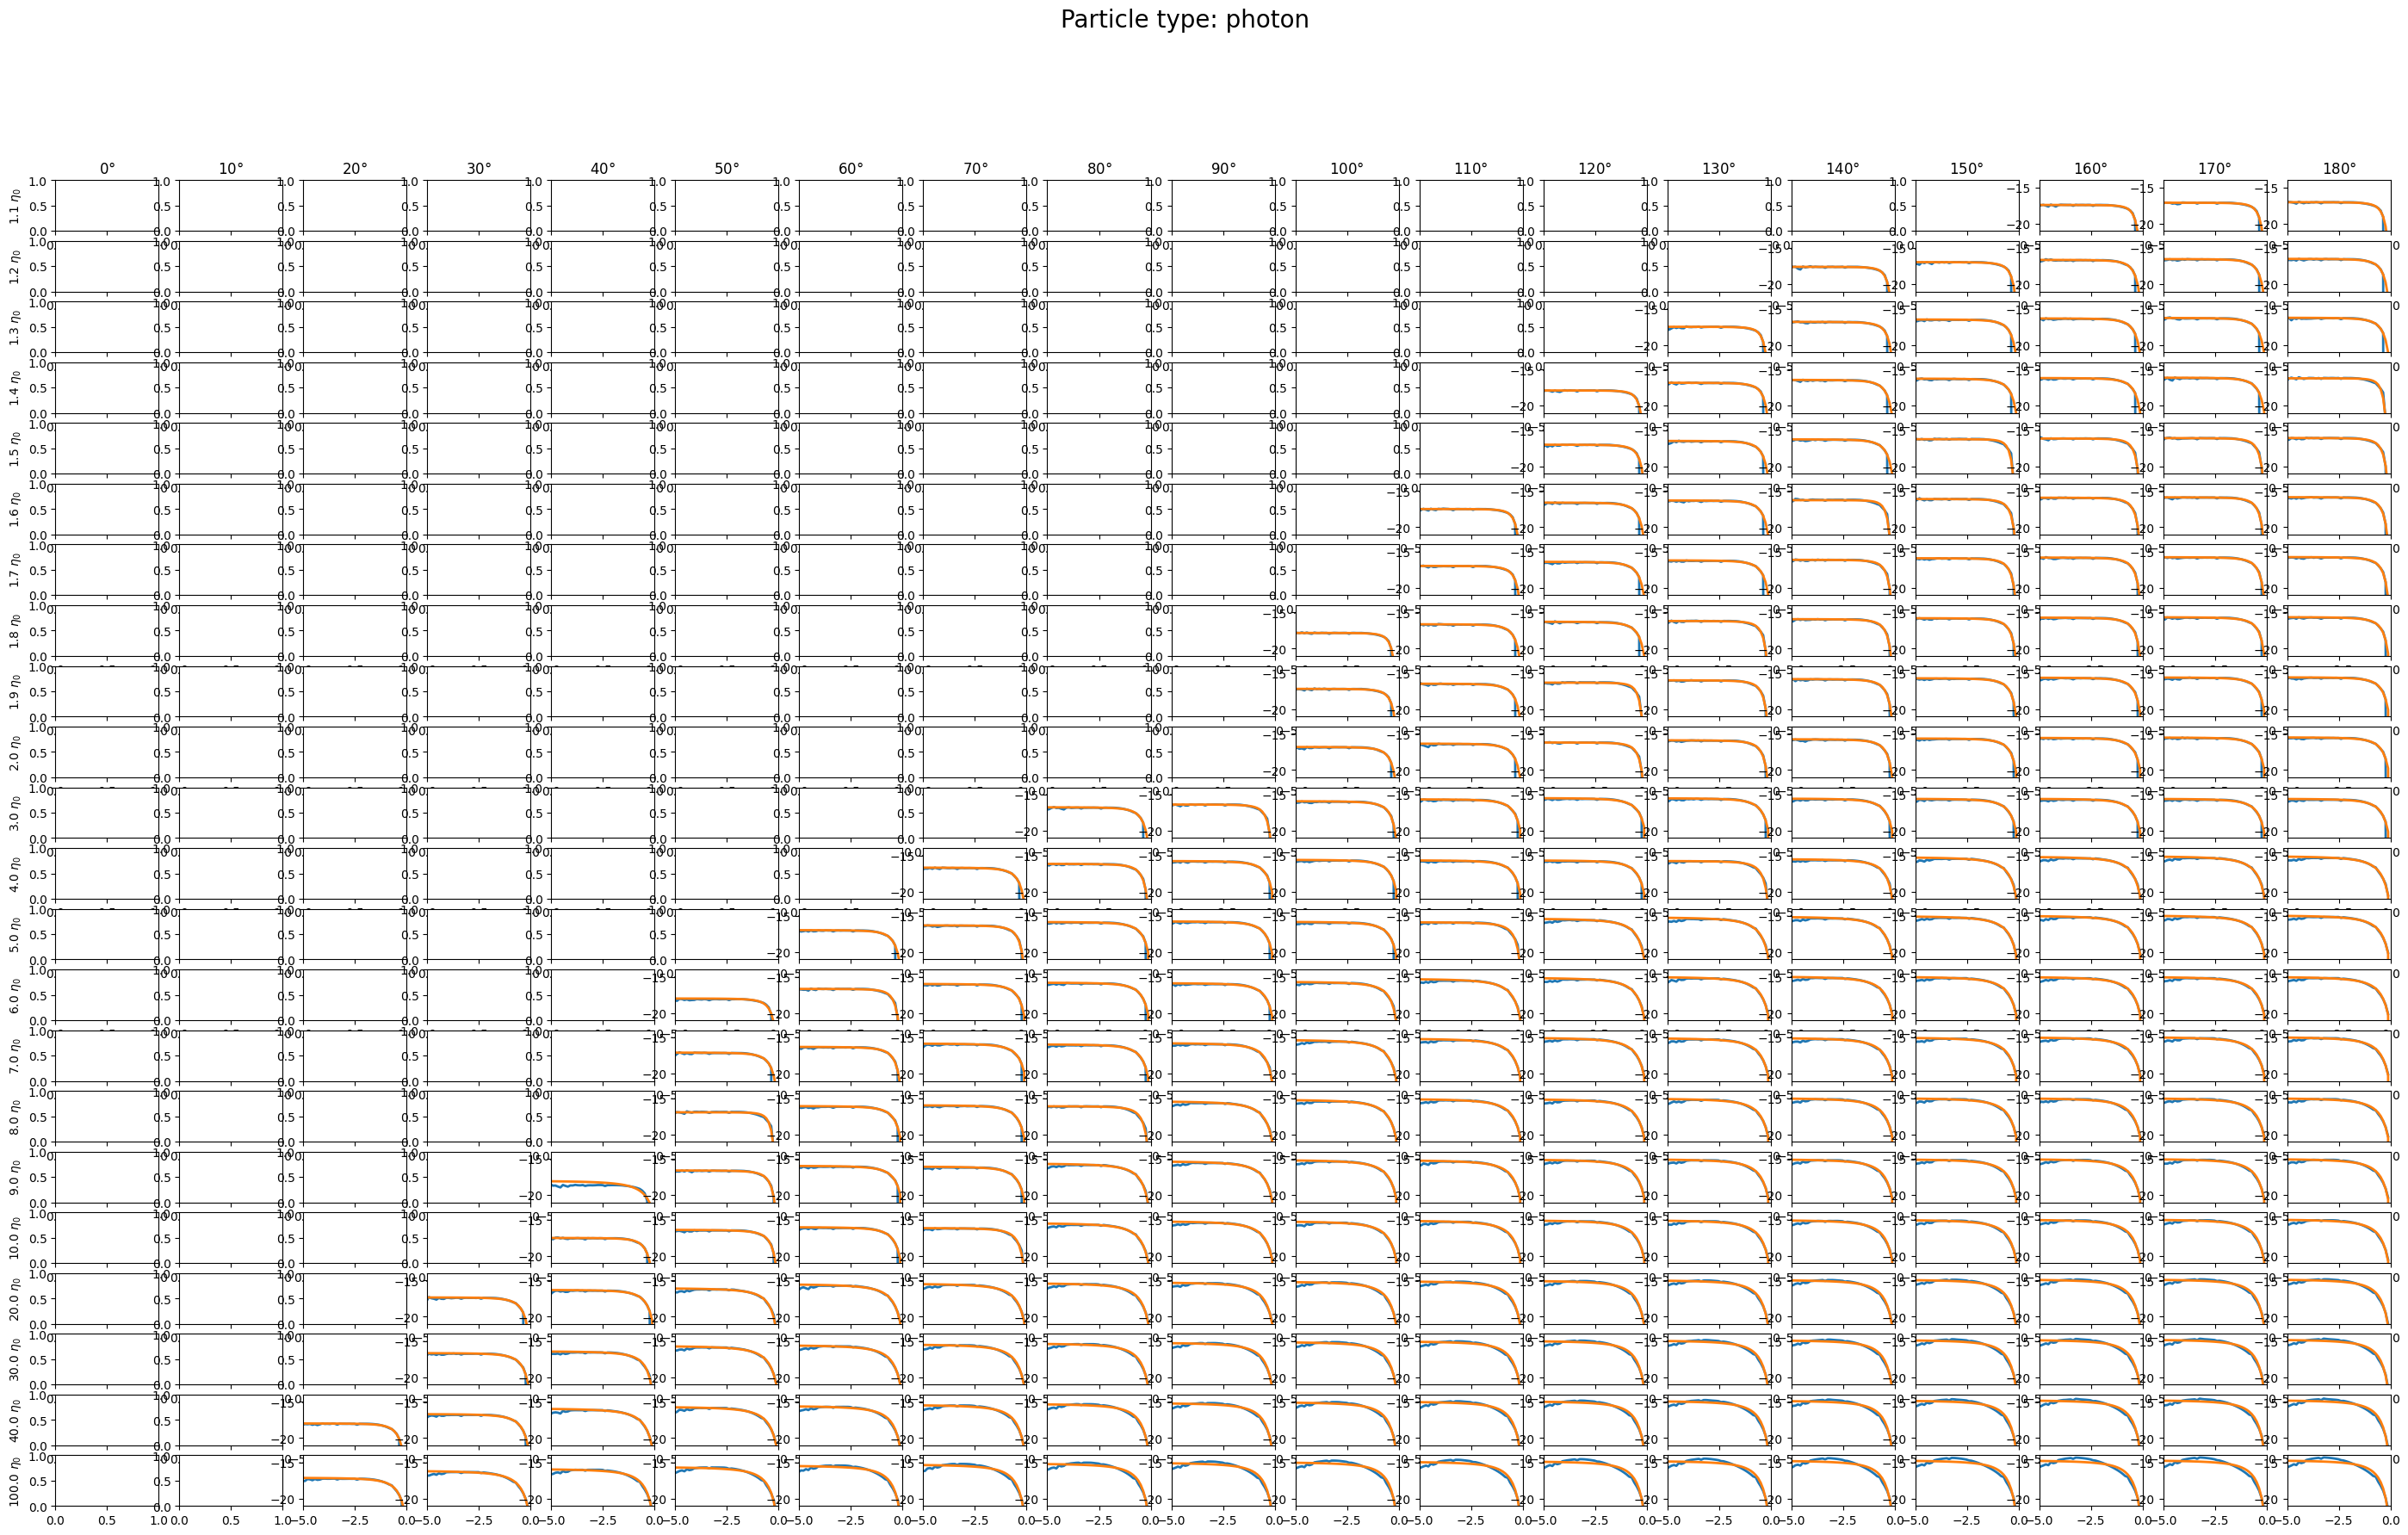

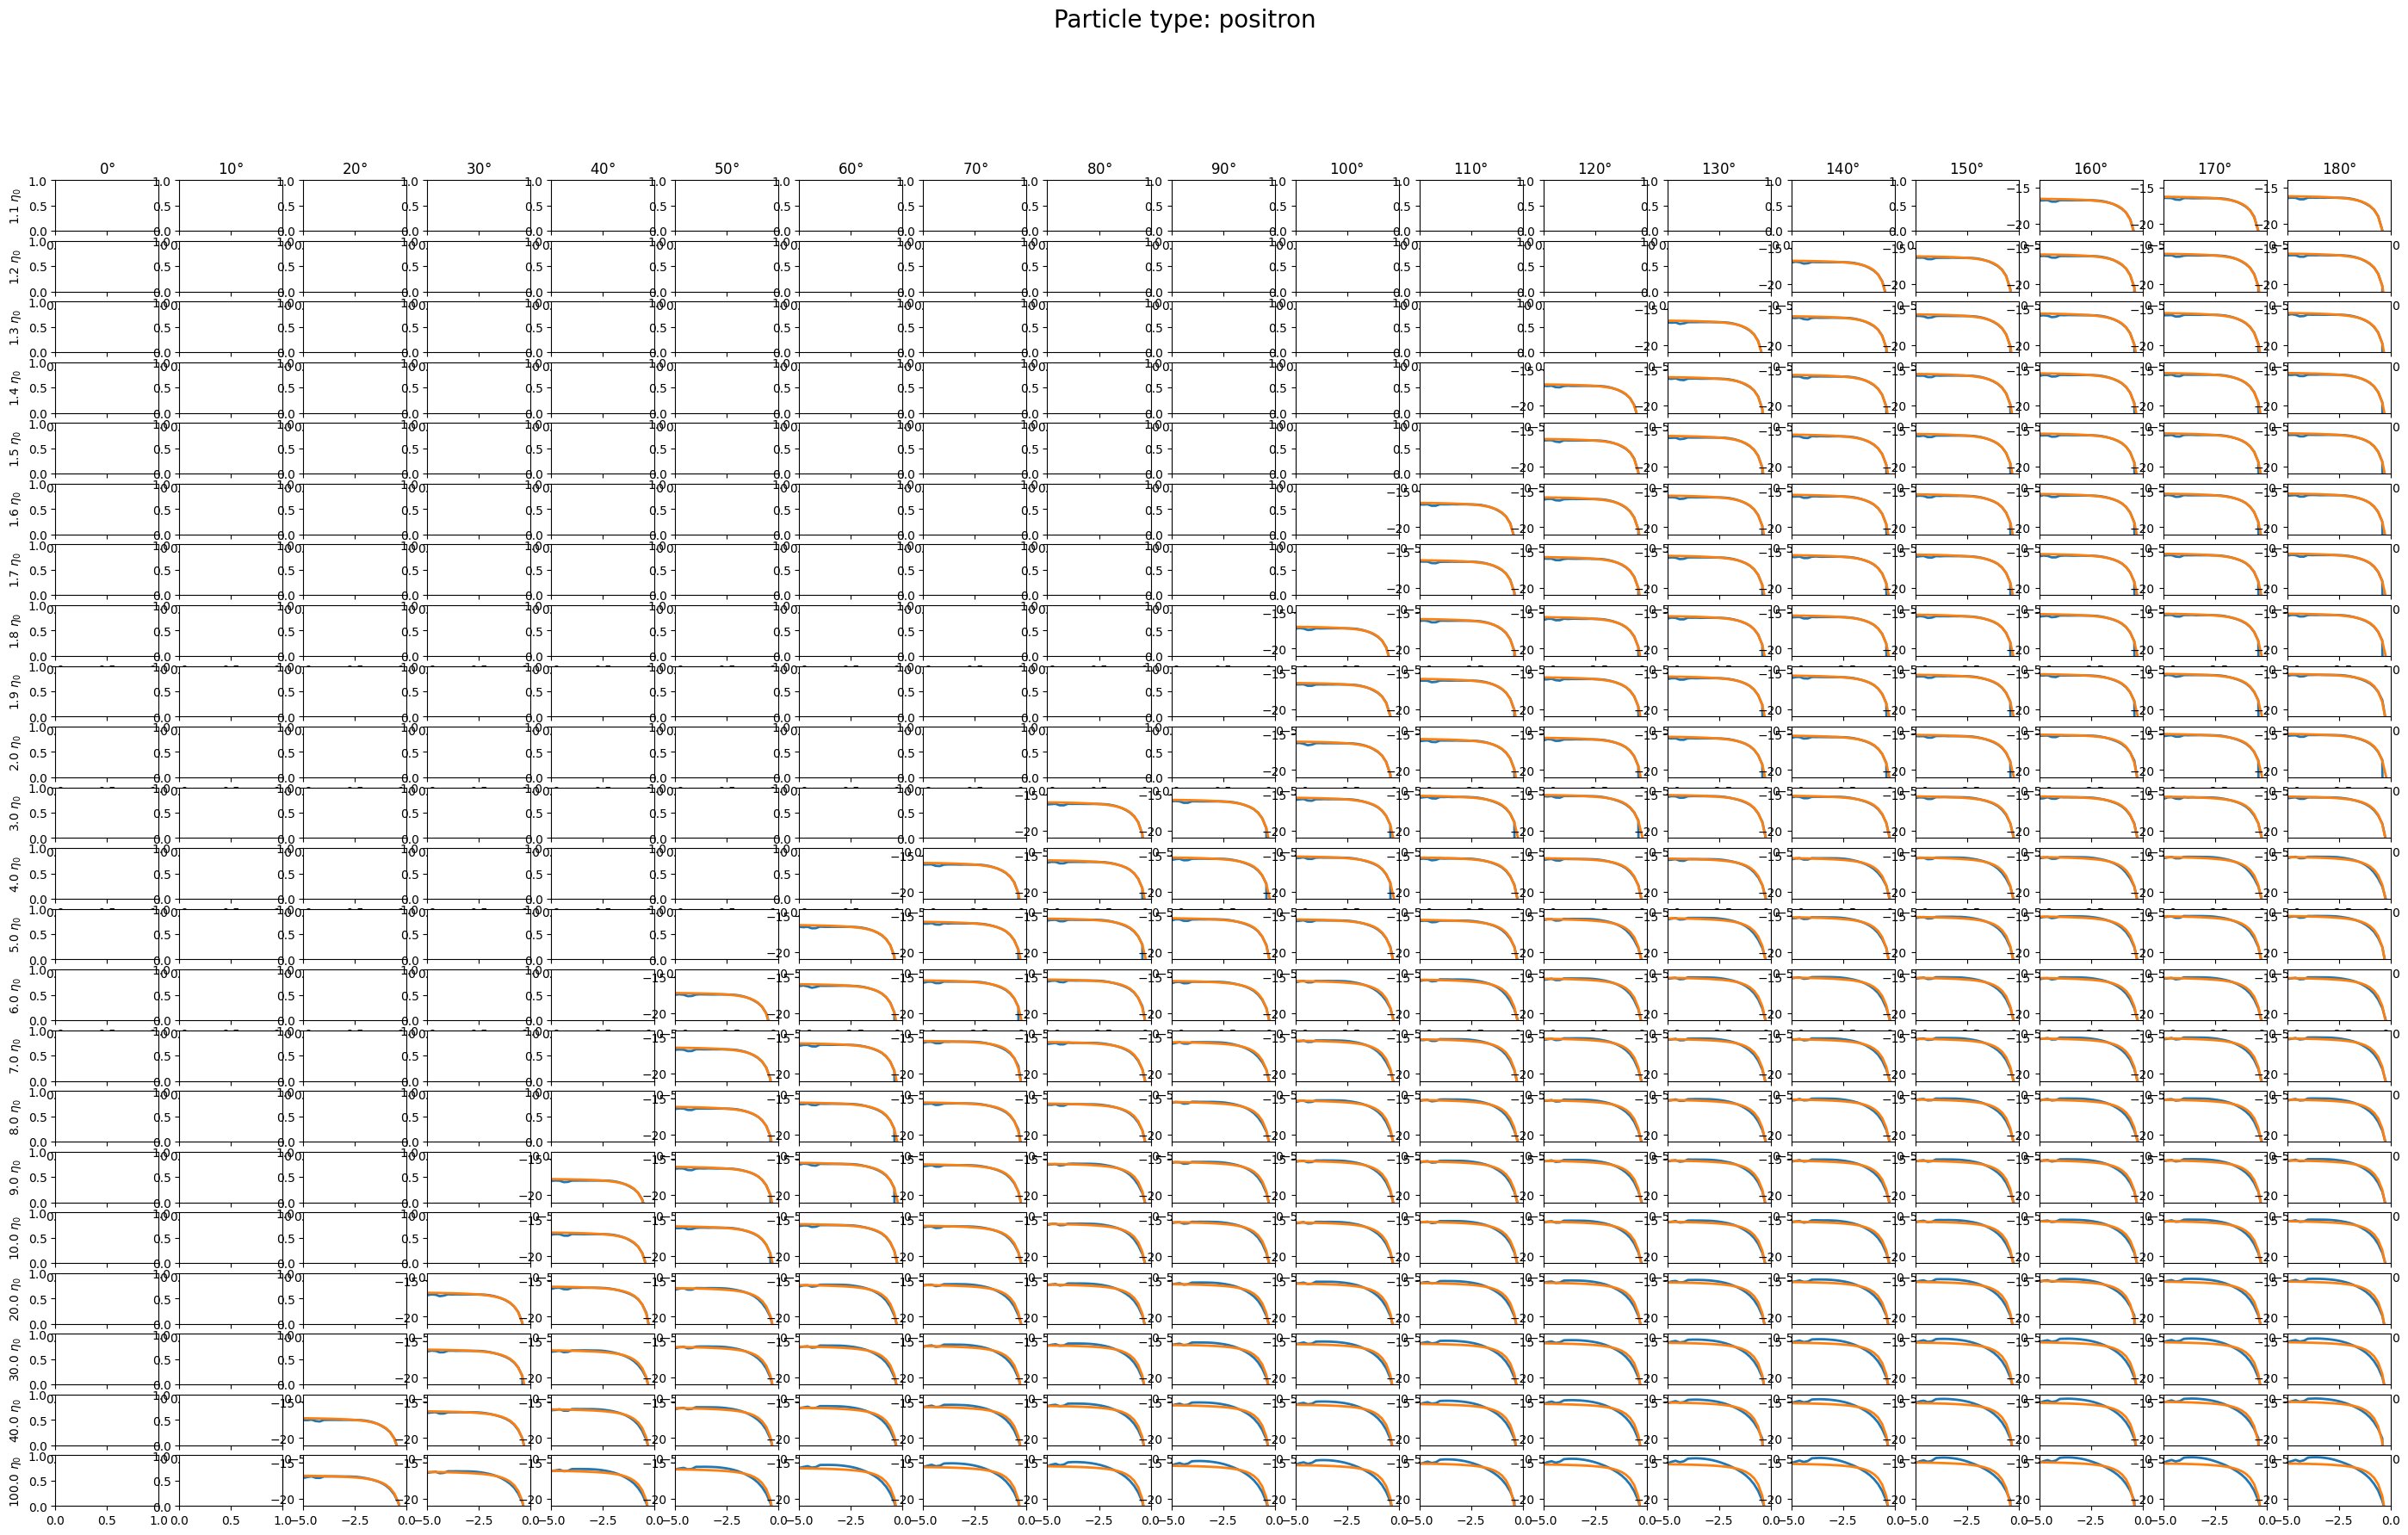

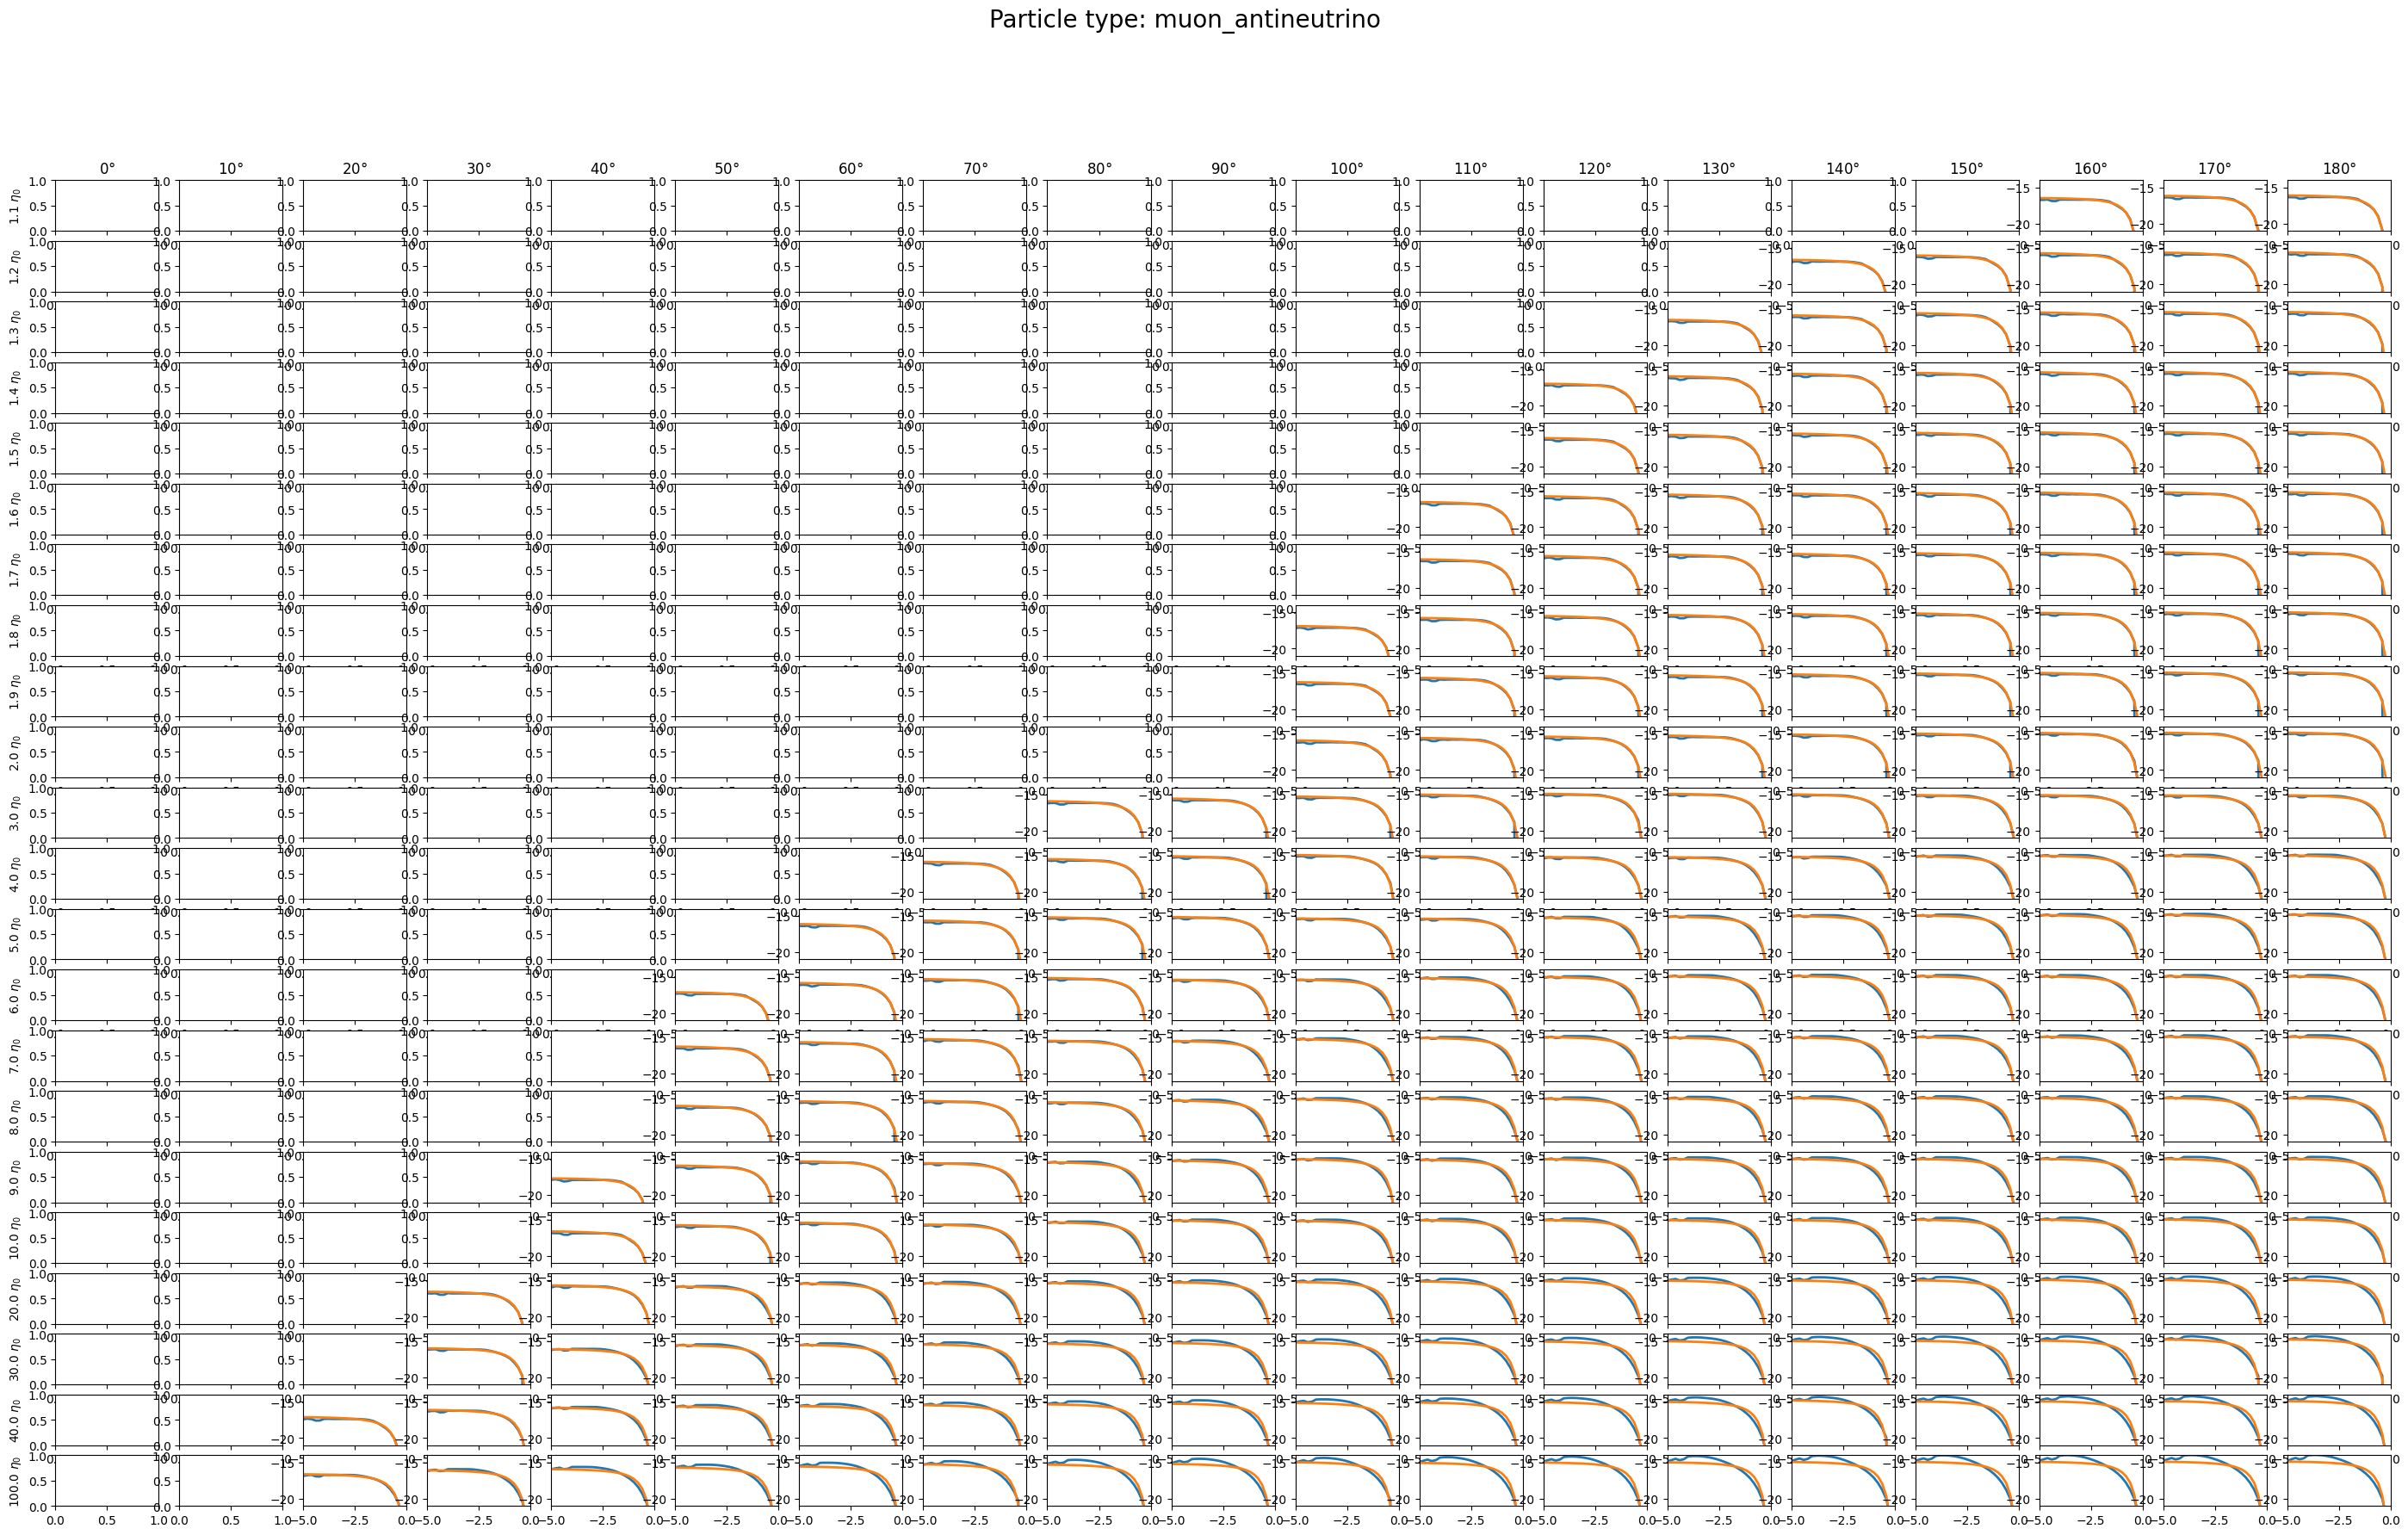

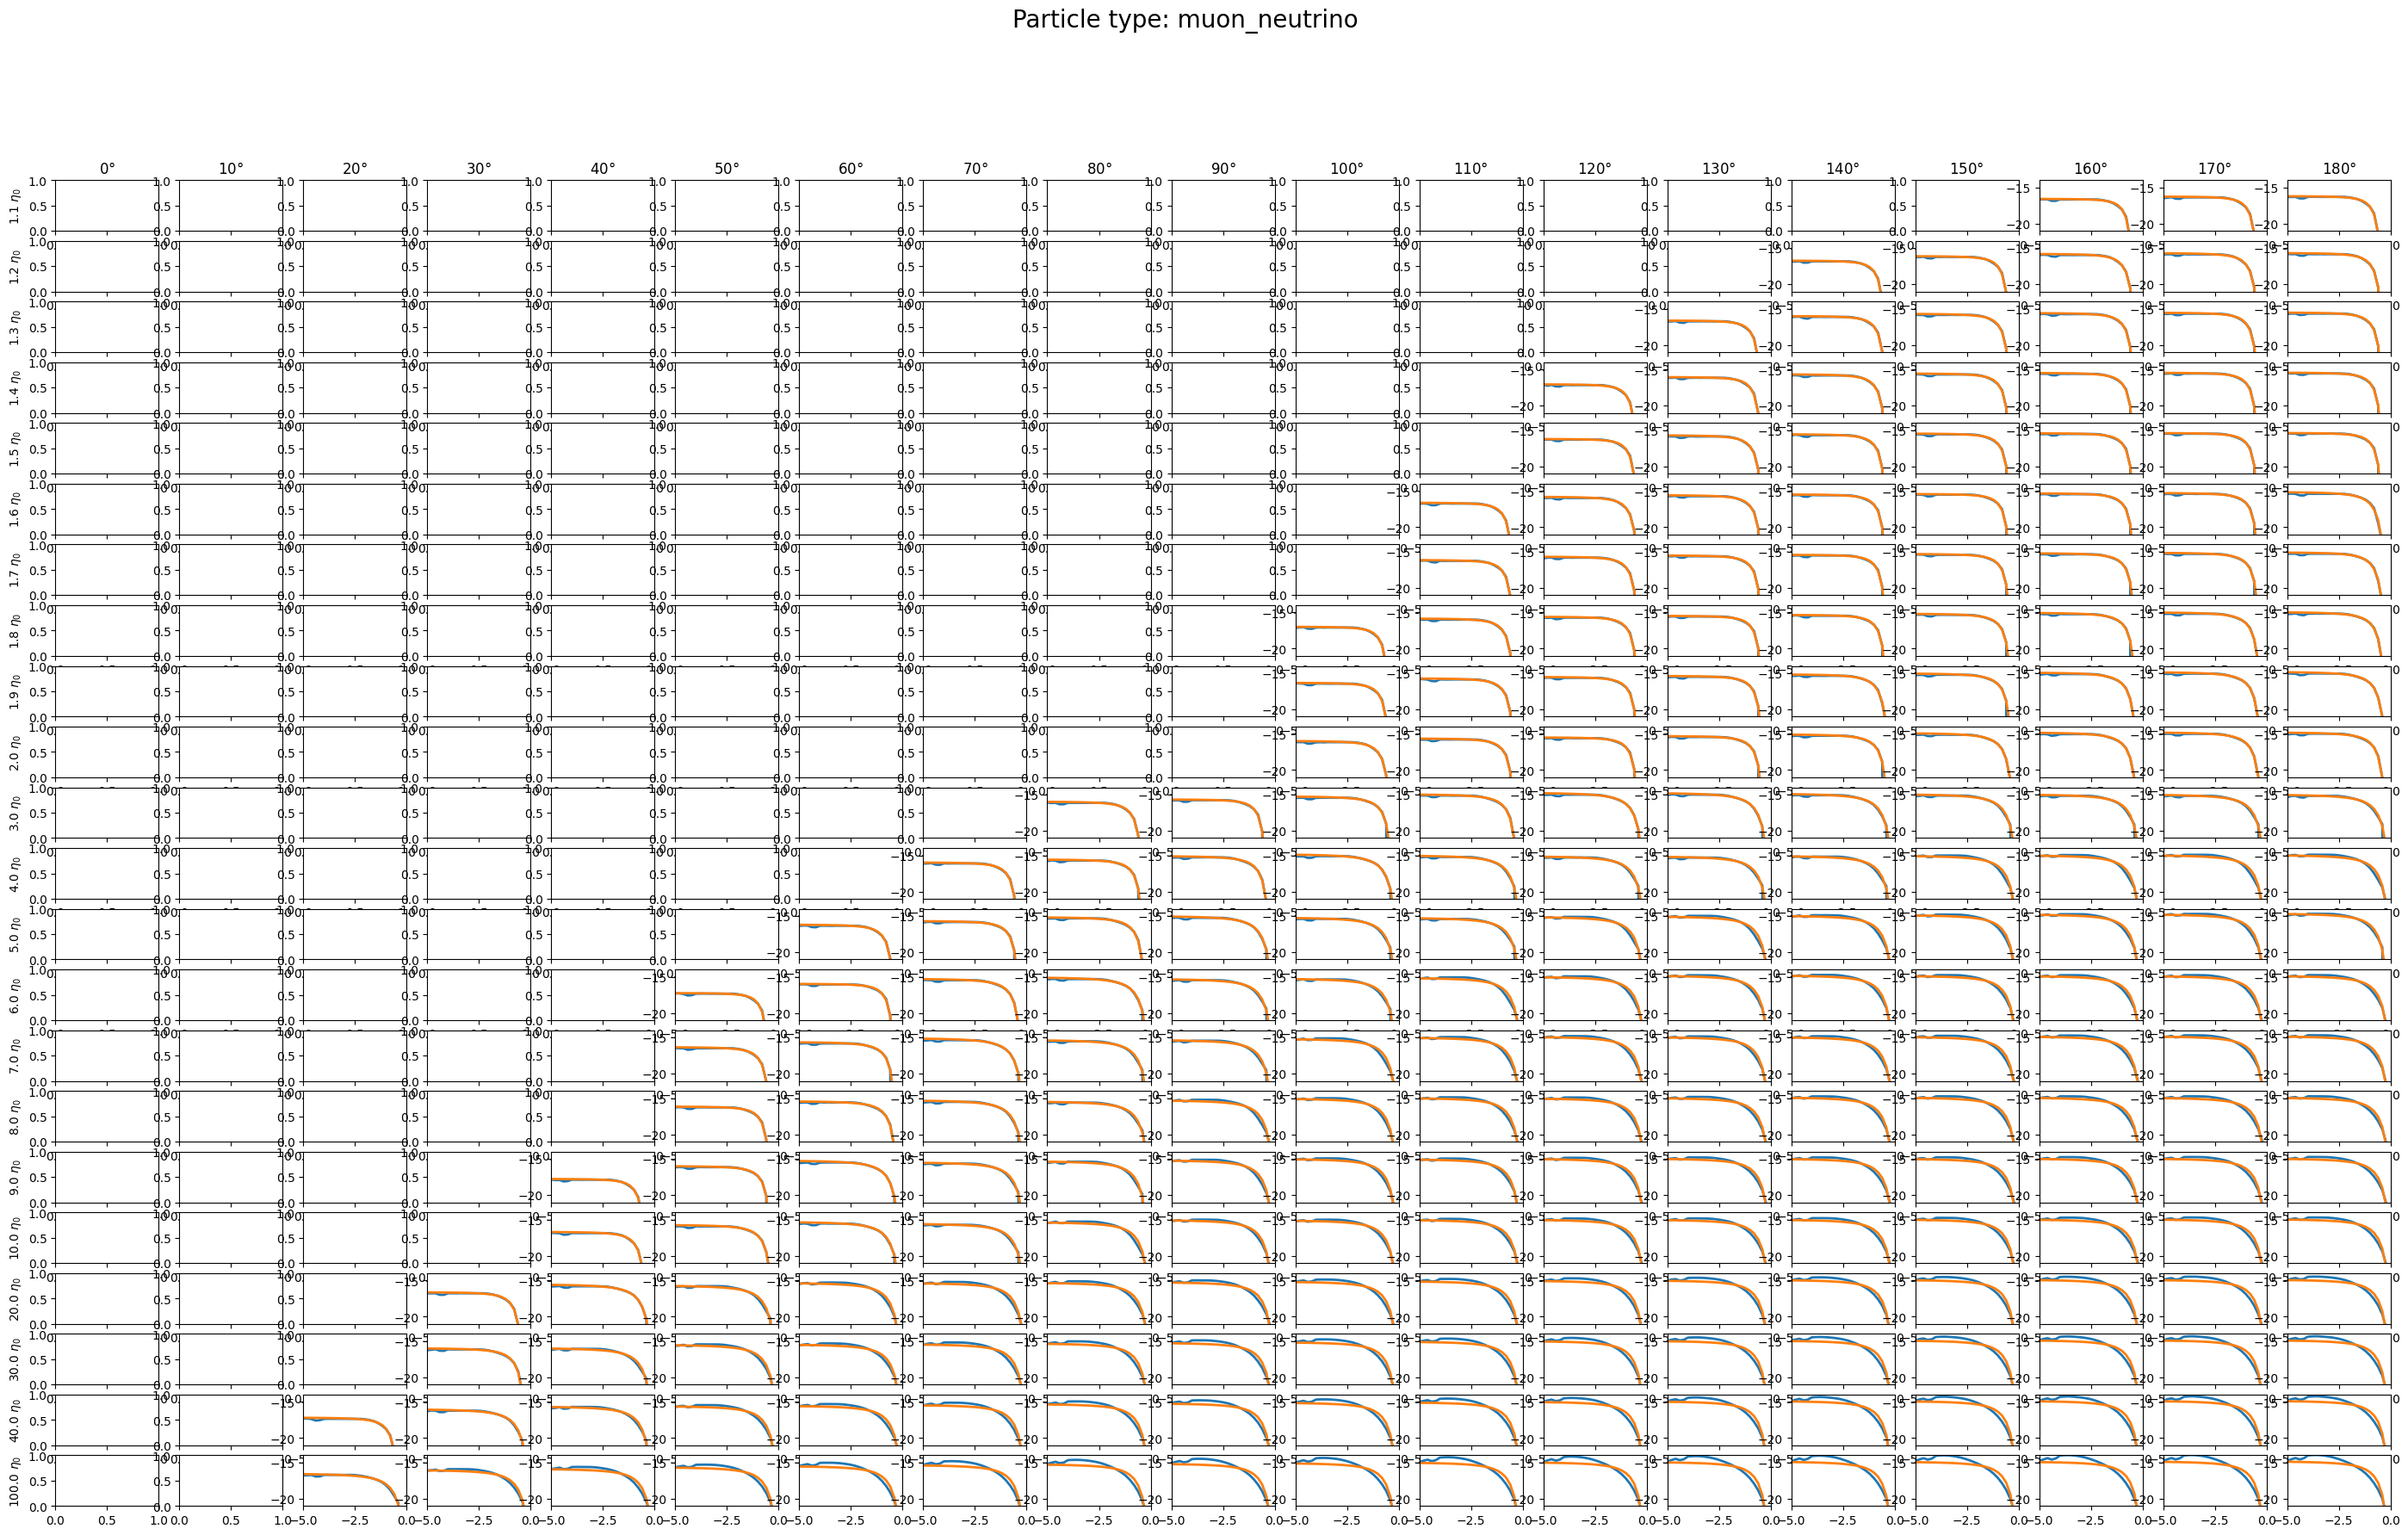

In [9]:
fit_plot("photon")
fit_plot("positron")
fit_plot("muon_antineutrino")
fit_plot("muon_neutrino")

# fit_plot("electron")
# fit_plot("electron_antineutrino")
# fit_plot("electron_neutrino")

In [10]:
labels = ["A","B","C","D"]

class Fx:
    def __init__(self, particle):
        data = np.loadtxt(f"./integrand_values/Fx_{particle}.txt")

        eta_eta0 = data[:, 0]
        theta = data[:, 1]
        params = data[:, 2:]

        points = np.column_stack((eta_eta0*eta_0, theta))

        self.linear = LinearNDInterpolator(points, params)
        self.nearest = NearestNDInterpolator(points, params)

    def interp(self, eta, theta):
        pts = np.column_stack((np.atleast_1d(eta), np.atleast_1d(theta)))

        val = self.linear(pts)
        mask = np.isnan(val)

        if np.any(mask):
            val[mask] = self.nearest(pts)[mask]

        return val.squeeze()
    
    def __call__(self, x, eta, theta):
        
        popt = self.interp(eta, theta)

        return np.where(x<0.99, 10**F(np.log10(x), *popt), 0.)

def interp_check(particle, eta_eta0):
    
    FF = Fx(particle)
    theta = np.linspace(0,180,19)
    vals = np.array([FF.interp(eta_eta0*eta_0, thetai) for thetai in theta])
    # print(vals[:,0])
    
    data = np.loadtxt(f"./integrand_values/Fx_{particle}.txt")

    filtered = data[data[:, 0] == eta_eta0]

    data_theta = filtered[:, 1]
    data_params = filtered[:, 2:]
    data_params = np.column_stack(data_params)
    
    # print(data_params[0])

    fig, ax = plt.subplots(1,4,figsize = (20, 9))
    
    # A*np.pow(E,(x-B)*C)+D
    fig.suptitle(r"f = A $\cdot$ E$^{C \cdot (x - B)}$ + D,"+rf"   $\eta$ = {eta_eta0} $\eta_{0}$",fontsize=15)

    for i in range(0,4):
        ax[i].plot(theta,vals[:,i])
        ax[i].scatter(data_theta,data_params[i])
        ax[i].set_title(labels[i])
        
        ax[i].set_xlim(0,180)
        if i == 0:
            ax[i].set_ylim(-50,-15)

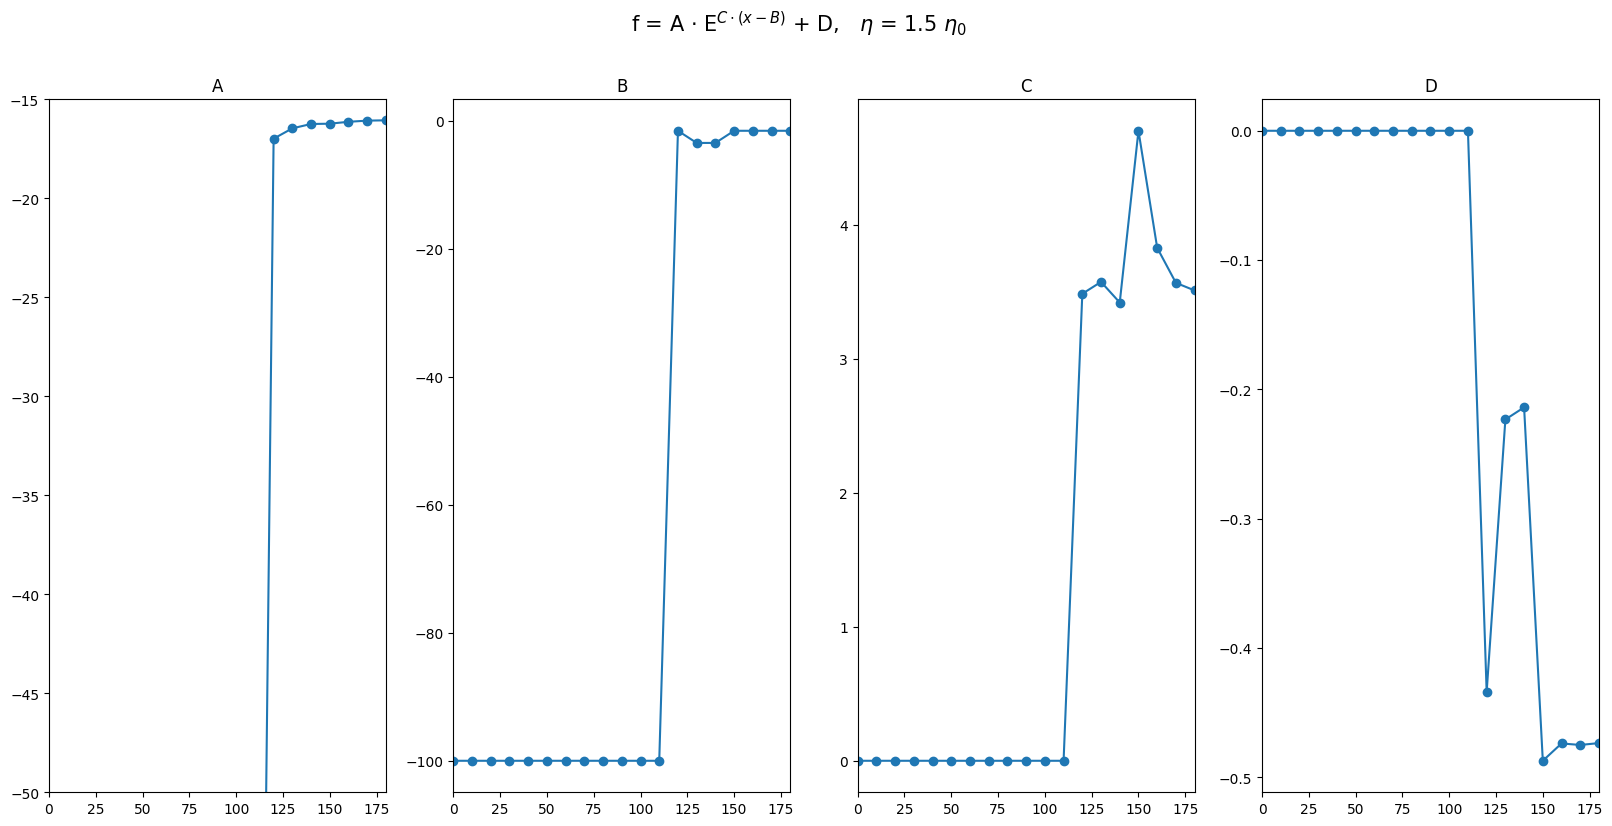

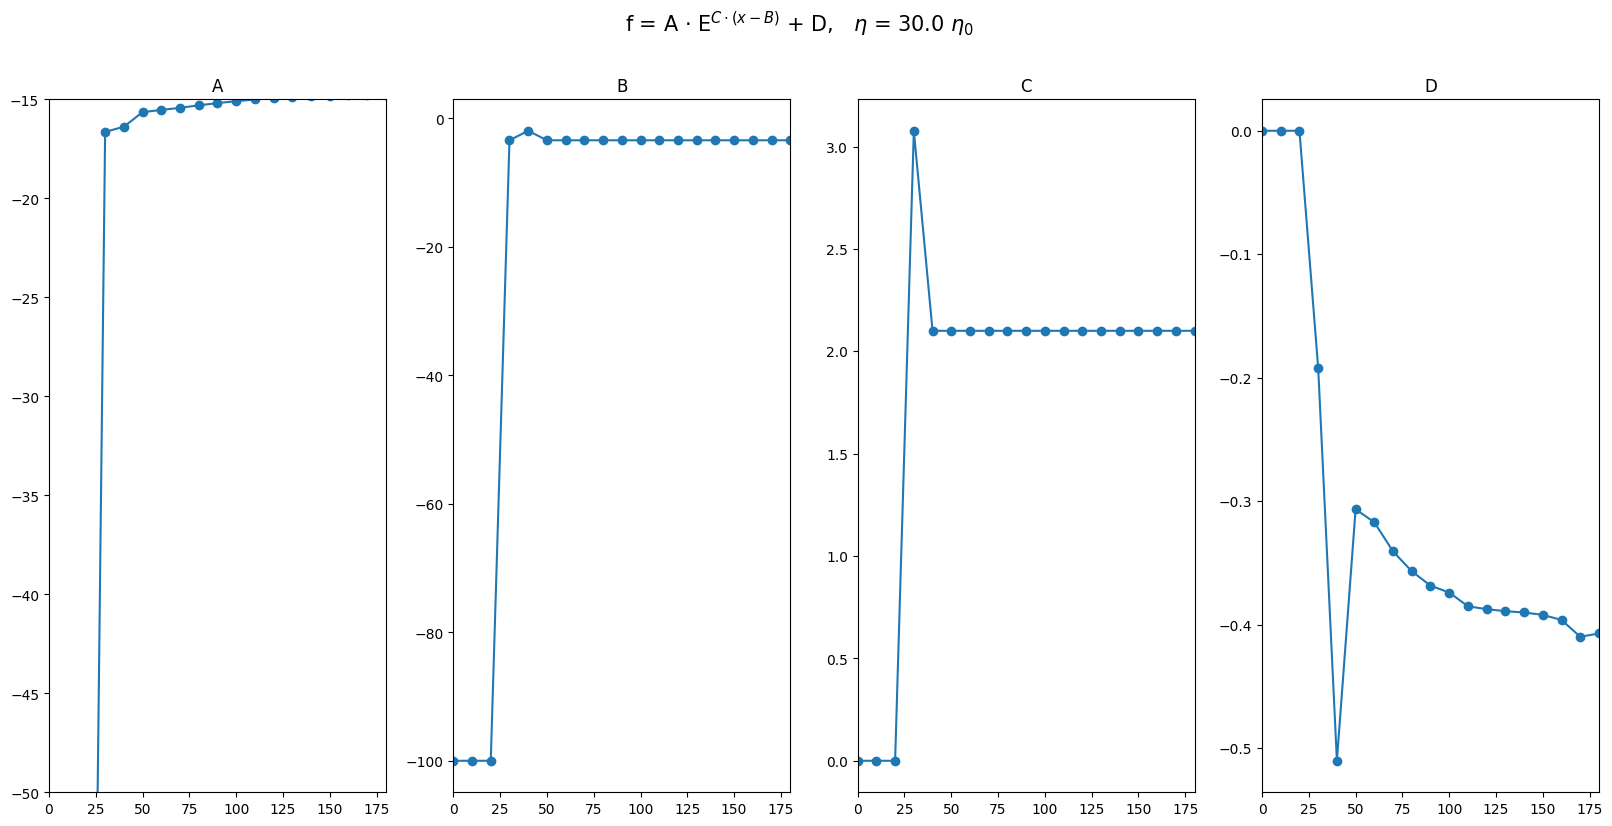

In [11]:
interp_check("photon",1.5)
interp_check("photon",30.0)

In [12]:
def part_label(particle):
    if particle == "photon":
        return r"\gamma"
    if particle == "positron":
        return r"e^{+}"
    if particle == "muon_antineutrino":
        return r"\bar{\nu}_{\mu}"
    if particle == "muon_neutrino":
        return r"\nu_{\mu}"

def plot_Phi(particle, eta_eta0):
    _x = np.logspace(-5,0,100)
    FF = Fx(particle)
    Y = []

    for xi in _x:

        theta = np.linspace(0., 180., 18*4)
        vals = np.array([FF(xi, eta_eta0*eta_0, thetai)*np.sin(thetai*np.pi/180.) for thetai in theta])
        # print(vals)
        result = np.trapezoid(vals, theta)/2.*np.pi/180.
        Y.append(result*xi)

    # print(Y)

    fig, ax = plt.subplots(1,1,figsize = (8, 4))

    fig.suptitle(rf"Particle type: {particle},  $\eta$ = {eta_eta0} $\eta_{0}$")

    if particle == "photon":
        interp_file = (f"./kelner_aharonian_2008/fig2_values/gamma_{eta_eta0}eta0.txt")
    if particle == "positron":
        interp_file = (f"./kelner_aharonian_2008/fig3_values/positron_{eta_eta0}eta0.txt")
    if particle == "muon_antineutrino":
        interp_file = (f"./kelner_aharonian_2008/fig4_values/muon_antineutrino_{eta_eta0}eta0.txt")
    if particle == "muon_neutrino":
        interp_file = (f"./kelner_aharonian_2008/fig5_values/muon_neutrino_{eta_eta0}eta0.txt")
    
    x_i, spectrum = np.genfromtxt(
        interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
    )

    x_i = np.power(10,x_i)
    spectrum = np.power(10,spectrum)

    ax.loglog(x_i,spectrum,lw=5,label=r"K&A")

    ax.loglog(_x,Y)
    
    ax.set_xlabel(rf"x = E$_{{{part_label(particle)}}}$ / E$_p$")
    ax.set_ylabel(rf"x $\phi_{{{part_label(particle)}}}$($\eta$,x)")

    if(eta_eta0 == 1.5):
        ax.set_xlim(1e-4,1e0)
        ax.set_ylim(1e-21,1e-18)
    if(eta_eta0 == 30):
        ax.set_xlim(1e-4,1e0)
        ax.set_ylim(1e-20,1e-17)

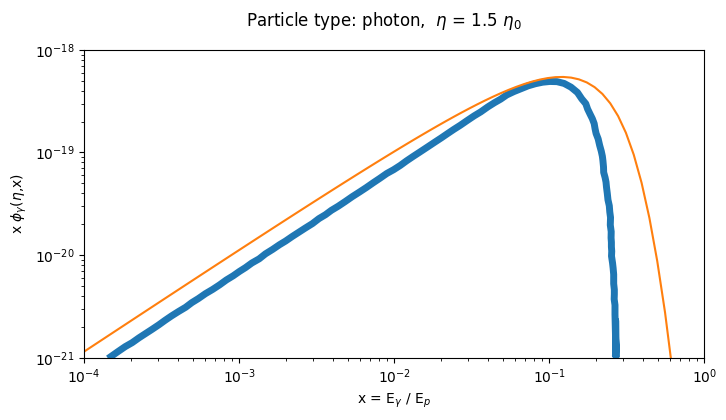

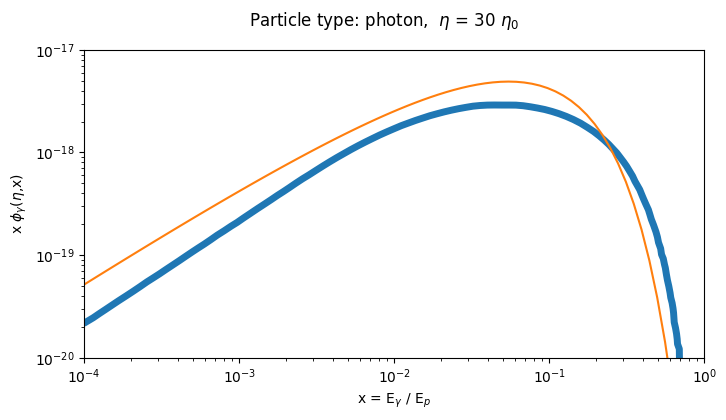

In [13]:
particle = "photon"
plot_Phi(particle,1.5)
plot_Phi(particle,30)

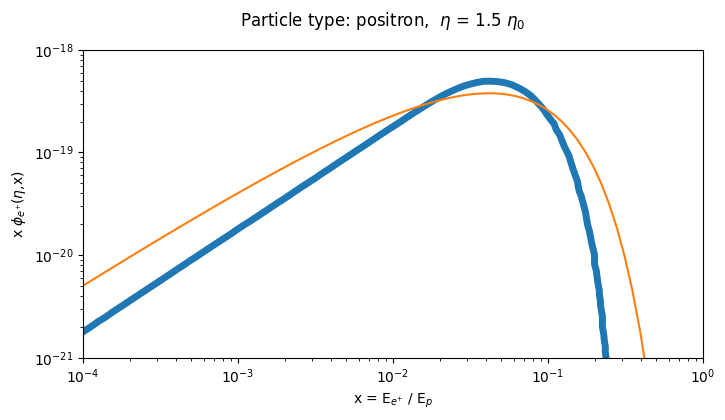

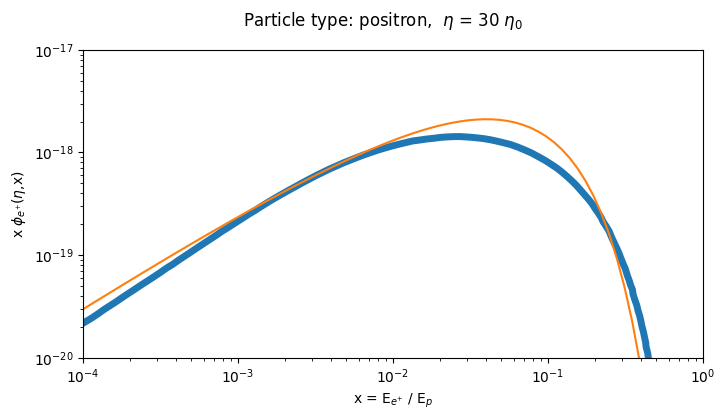

In [14]:
particle = "positron"
plot_Phi(particle,1.5)
plot_Phi(particle,30)

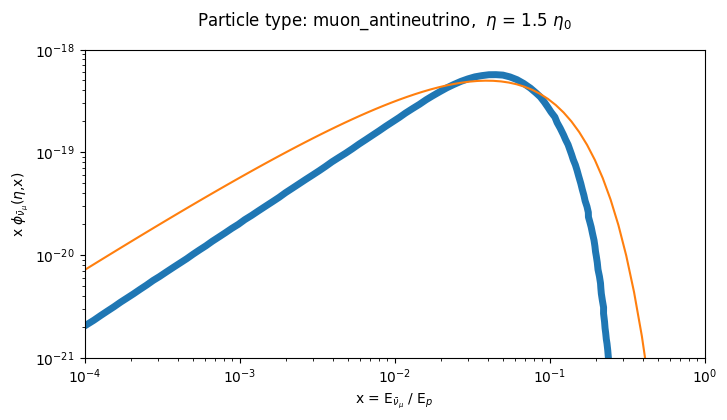

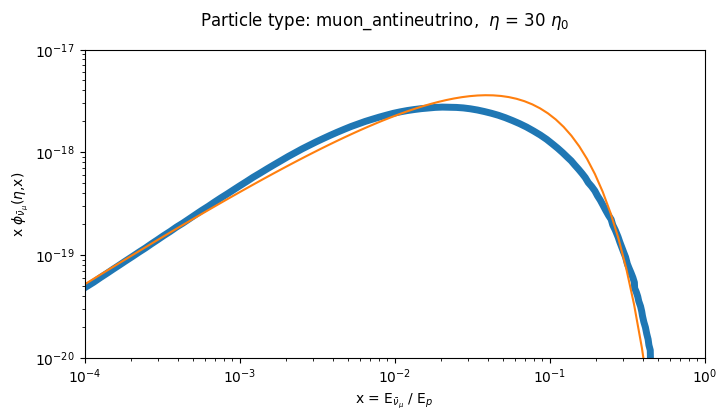

In [15]:
particle = "muon_antineutrino"
plot_Phi(particle,1.5)
plot_Phi(particle,30)

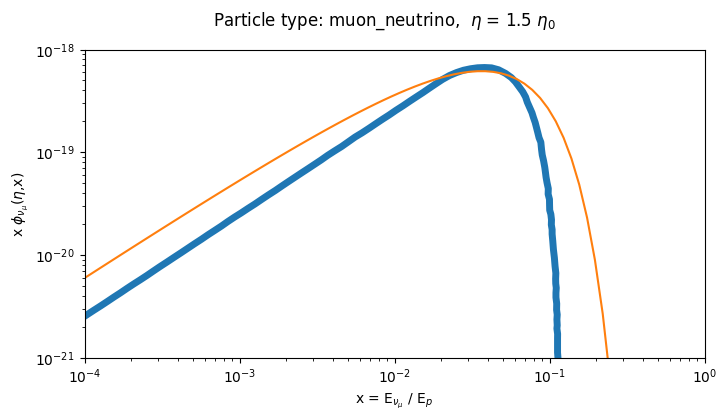

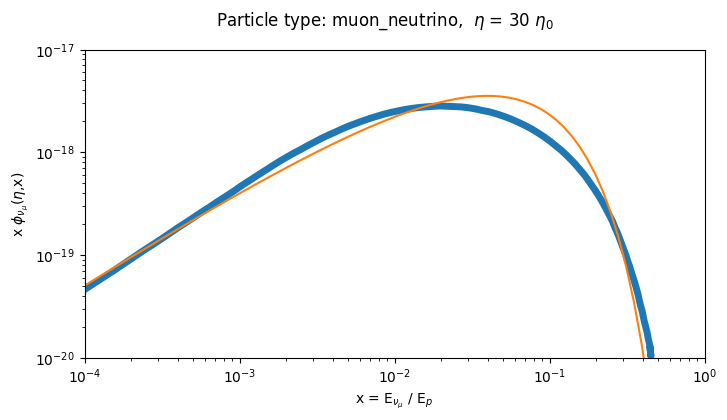

In [16]:
particle = "muon_neutrino"
plot_Phi(particle,1.5)
plot_Phi(particle,30)